In [1]:
!pip install -q transformers==4.40.0 datasets peft==0.10.0 trl==0.8.1 bitsandbytes accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 15.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [2]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
secret_hf_token = user_secrets.get_secret("HF_TOKEN")
login(secret_hf_token)

import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer

model_id = "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B" 

print("Impartire train/validate")
data_path = "/kaggle/input/datasets/denisastan/exercitii1/exercises_merged.json"
dataset = load_dataset("json", data_files=data_path, split="train")
dataset = dataset.train_test_split(test_size=0.1, seed=42)

SYSTEM_PROMPT = (
    "Ești SmartBAC, un asistent de matematică specializat pe exerciții de Bacalaureat. "
    "Gândește pas cu pas în blocul <think>, apoi dă răspunsul final. "
    "Răspunde în limba română."
)

def formateaza_prompt(exemplu):
    question = exemplu.get("question") or ""
    answer = exemplu.get("answer") or ""
    steps = exemplu.get("solution_steps") or exemplu.get("steps") or []
    solution = exemplu.get("solution") or ""
    thinking = ""
    if isinstance(steps, list) and len(steps) > 0:
        thinking = "\n".join(str(s) for s in steps if s and str(s).strip())
    elif isinstance(solution, str) and len(solution.strip()) > 10:
        thinking = solution.strip()
    else:
        thinking = f"Rezolvare directă: {answer}"
    text = (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{question}<|im_end|>\n"
        f"<|im_start|>assistant\n<think>\n{thinking}\n</think>\n\nRăspuns: {answer}<|im_end|>"
    )
    return {"text": text}

dataset = dataset.map(formateaza_prompt)

print("Incarcare model pe 4-biti (QLoRA)")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model.gradient_checkpointing_enable() 
model.enable_input_require_grads()  
model.config.use_cache = False

print("Antrenare strat subtire")
peft_config = LoraConfig(
    r=16, 
    lora_alpha=32, 
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], 
    lora_dropout=0.05, 
    bias="none", 
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, peft_config)

print("Configurare parametrii")
training_args = TrainingArguments(
    output_dir="./rezultate_AI",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,     
    eval_accumulation_steps=1,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    learning_rate=5e-5,
    num_train_epochs=1,
    logging_steps=10,
    evaluation_strategy="steps", 
    eval_steps=50,
    save_steps=50,
    logging_strategy="steps",                  
    save_strategy="epoch",         
    logging_first_step=True, 
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    disable_tqdm=False,
    optim="paged_adamw_8bit",
    fp16=True,
    report_to="none"
)

trainer = SFTTrainer(
    model=model,
    train_dataset = dataset["train"], 
    eval_dataset = dataset["test"],
    peft_config=peft_config,
    dataset_text_field="text",
    max_seq_length=1024,
    tokenizer=tokenizer,
    args=training_args
)

trainer.train()

model_name = "deniii1111/bac-math-qwen-lora" 
trainer.model.push_to_hub(model_name)
tokenizer.push_to_hub(model_name)

print("Model salvat")

2026-04-06 14:03:02.713526: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775484183.088719      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775484183.200863      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775484184.144592      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775484184.144638      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775484184.144641      23 computation_placer.cc:177] computation placer alr

Impartire train/validate


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/4086 [00:00<?, ? examples/s]

Map:   0%|          | 0/455 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Model salvat


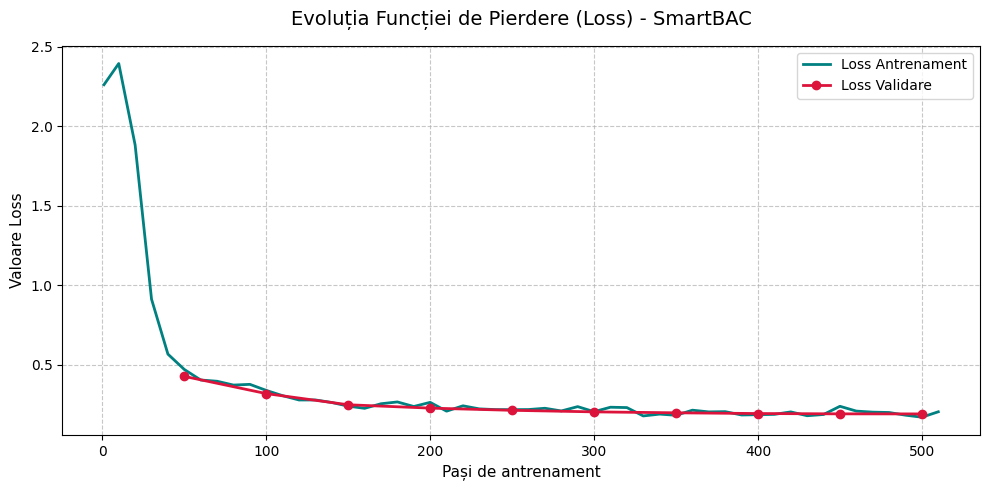

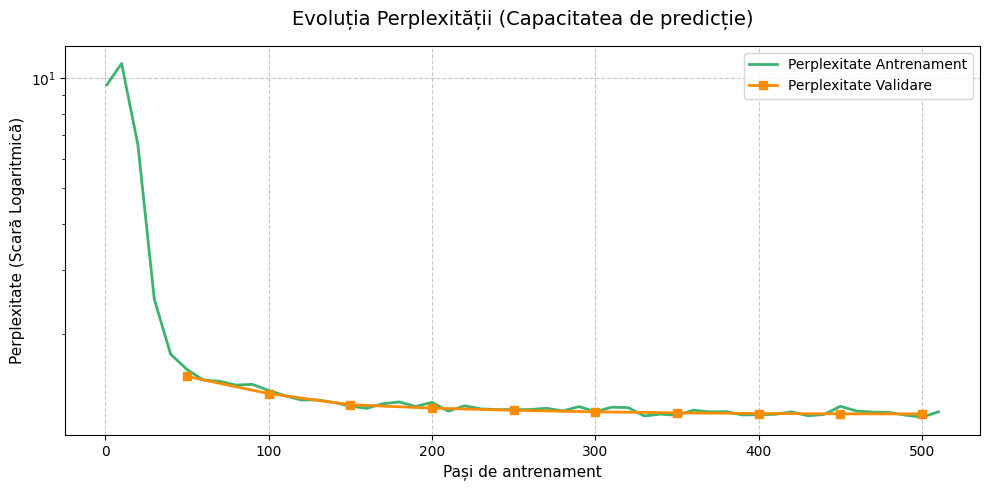

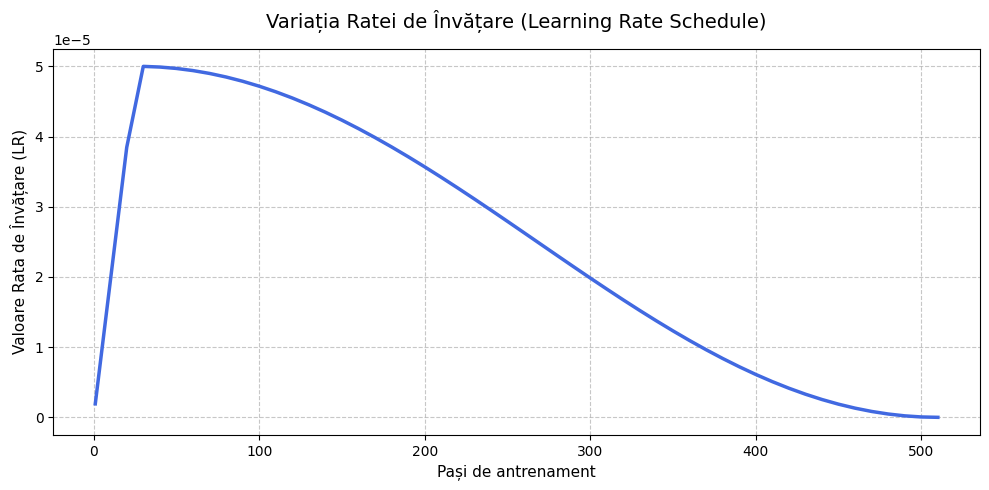

In [3]:
import matplotlib.pyplot as plt
import numpy as np

istoric = trainer.state.log_history
pasi_train, loss_train, pasi_lr, lr_val = [], [], [], []
pasi_eval, loss_eval = [], []

for log in istoric:
    if "loss" in log and "step" in log:
        pasi_train.append(log["step"])
        loss_train.append(log["loss"])
    if "learning_rate" in log and "step" in log:
        pasi_lr.append(log["step"])
        lr_val.append(log["learning_rate"])
    if "eval_loss" in log and "step" in log:
        pasi_eval.append(log["step"])
        loss_eval.append(log["eval_loss"])

ppl_train = [np.exp(l) for l in loss_train]
ppl_eval = [np.exp(l) for l in loss_eval]

plt.figure(figsize=(10, 5))
plt.plot(pasi_train, loss_train, label="Loss Antrenament", color="teal", linewidth=2)
plt.plot(pasi_eval, loss_eval, label="Loss Validare", color="crimson", marker="o", linewidth=2, markersize=6)

plt.title("Evoluția Funcției de Pierdere (Loss) - SmartBAC", fontsize=14, pad=15)
plt.xlabel("Pași de antrenament", fontsize=11)
plt.ylabel("Valoare Loss", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("grafic_loss_smartbac.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(pasi_train, ppl_train, label="Perplexitate Antrenament", color="mediumseagreen", linewidth=2)
plt.plot(pasi_eval, ppl_eval, label="Perplexitate Validare", color="darkorange", marker="s", linewidth=2, markersize=6)

plt.title("Evoluția Perplexității (Capacitatea de predicție)", fontsize=14, pad=15)
plt.xlabel("Pași de antrenament", fontsize=11)
plt.ylabel("Perplexitate (Scară Logaritmică)", fontsize=11)
plt.yscale('log')
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("grafic_perplexitate_smartbac.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(pasi_lr, lr_val, color="royalblue", linewidth=2.5)

plt.title("Variația Ratei de Învățare (Learning Rate Schedule)", fontsize=14, pad=15)
plt.xlabel("Pași de antrenament", fontsize=11)
plt.ylabel("Valoare Rata de Învățare (LR)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("grafic_learning_rate.png", dpi=300)
plt.show()